In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 
sys.path.append('/home/cosweeney/code/Fits/')

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h
print(cosmo.h, cosmo.Hz(redshift), cosmo.H0*cosmo.Ez(redshift))

sys.path.append('/home/cosweeney/code/Fits/')

sys.path.append('/home/cosweeney/code/Fits/Jocond')

from JoCond.jocond.losvd import *
from JoCond.jocond.cat import *
from JoCond.jocond.hgcf import *
from JoCond.jocond.myconfig import*

import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

from scipy.stats import gennorm, norm, t
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import curve_fit


0.6777 74.71913613009617 74.71913613009617


In [2]:
Rvirs, Mvirs, mbins = compute_bin_virial_R_M('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5')

# radial bins, just out to 30/40 for now
r_edges = np.linspace(5, 30, (30-5)+1)
r_cens = (r_edges[1:]+r_edges[:-1])/2.0 

rlos_edges = np.linspace(0, 40, (40-0)+1)
rlos_cens = (rlos_edges[1:]+rlos_edges[:-1])/2.0 

massbin edges, in h^-1 sol mass: [8.00020227e+13 1.22732852e+14 1.88287152e+14 2.88855436e+14
 4.43139440e+14 6.79829904e+14 1.60000000e+15]


In [3]:
# bin sim data in bins of R
#vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_cyl_6K_indmass.hdf5'
vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_no_vlos_cut_lowmass.hdf5'

vpeclos  = []
vphyslos = []
rlos_R = []
R_R = []
M_R = []

with h5.File(vel_path, 'r') as hdf:
    for k in range(len(Mvirs)):
        rel_R = hdf[f'R/{k}'][()]
        rel_rlos = hdf[f'rlos/{k}'][()]
        vpec = hdf[f'vpeclos/{k}'][()]
        vphys = hdf[f'vphyslos/{k}'][()]
        Mvir = hdf[f'Mvir/{k}'][()]
        
        # Use digitize to bin all at once
        bin_indices = np.digitize(rel_R, r_edges) - 1
        
        for i in range(len(r_cens)):
            mask = bin_indices == i
            vpeclos.append(vpec[mask])
            vphyslos.append(vphys[mask])
            rlos_R.append(rel_rlos[mask])
            R_R.append(rel_R[mask])
            M_R.append(Mvir[mask])

In [4]:
# and now bins of R, rlos
vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_no_vlos_cut_lowmass.hdf5'

vpeclos1 = []
vphyslos1 = []
R1 = []
rlos1 = []

with h5.File(vel_path, 'r') as hdf:
    for k in range(len(Mvirs)):
        rel_R = hdf[f'R/{str(k)}'][()]
        rel_rlos = hdf[f'rlos/{str(k)}'][()]
        vpec = hdf[f'vpeclos/{str(k)}'][()]
        vphys = hdf[f'vphyslos/{str(k)}'][()]
        
        for i, R in enumerate(r_cens):
            Rmask = (rel_R >= r_edges[i]) & (rel_R <= r_edges[i+1])
            rel_R_masked = rel_R[Rmask]
            rel_rlos_masked = rel_rlos[Rmask]
            vpec_masked = vpec[Rmask]
            vphys_masked = vphys[Rmask]

            
            for j, rlos in enumerate(rlos_cens):
                rmask = (rel_rlos_masked >= rlos_edges[j]) & (rel_rlos_masked <= rlos_edges[j+1])
                
                vpeclos1.append(vpec_masked[rmask])
                rlos1.append(rel_rlos_masked[rmask])
                R1.append(rel_R_masked[rmask])
                vphyslos1.append(vphys_masked[rmask])

In [5]:
v_r, rbin, vr_sbids = bin_velocities_abs(path='/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5', vel='v_r', binning='r', Rbins=rlos_edges, massbins=mbins, return_sbid=True) 

Number of bins: 240


In [5]:
# compute LS vr(r) profiles
r_edges_LS = np.linspace(0, 80, 80+1)
r_cens_LS = 0.5*(r_edges_LS[1:] + r_edges_LS[:-1])

vr_r = []

with h5.File(vel_path, 'r') as hdf:
    for k in range(len(Mvirs)):       
            rel_R = hdf[f'r/{str(k)}'][()]
            vr = hdf[f'vr/{str(k)}'][()]
            
            for i, R in enumerate(r_cens_LS):
                Rmask = (rel_R >= r_edges_LS[i]) & (rel_R <= r_edges_LS[i+1])
                vr_masked = vr[Rmask]

                vr_r.append(vr_masked)
        

In [ ]:
def skewed_t_pdf(x, xi, omega, alpha, nu):
    """
    Azzalini & Capitanio skewed t-distribution PDF
    
    Parameters:
    xi: location parameter
    omega: scale parameter (> 0)
    alpha: skewness parameter
    nu: degrees of freedom (> 0)
    """
    # Standardize
    z = (x - xi) / omega
    
    # Student's t PDF
    t_pdf = t.pdf(z, df=nu)
    
    # Student's t CDF with modified argument
    t_cdf = t.cdf(alpha * z * np.sqrt((nu + 1) / (nu + z**2)), df=nu + 1)
    
    # Skewed t PDF
    pdf = (2 / omega) * t_pdf * t_cdf
    
    return pdf

# plot <v_r|r>
mean_vr_r = np.zeros((len(Mvirs), len(r_cens_LS)))
peak_vr_r = np.zeros((len(Mvirs), len(r_cens_LS)))
peak_err_r = np.zeros((len(Mvirs), len(r_cens_LS)))


std_vr_r = np.zeros((len(Mvirs), len(r_cens_LS)))
std_vt_r = np.zeros((len(Mvirs), len(r_cens_LS)))
std_vlos_r = np.zeros((len(Mvirs), len(r_cens_LS)))

for k in range(len(Mvirs)):
    for i in range(len(r_cens_LS)):
        index = i + k*(len(r_cens_LS))

        hist, edges = np.histogram(vr_r[index], bins='auto', range=[-4000, 4000], density=True)
        cent = 0.5*(edges[1:] + edges[:-1])

        mean = np.mean(vr_r[index])

        try:
            p, c = curve_fit(skewed_t_pdf, cent, hist, p0=[cent[np.argmax(hist)], 300, -0.1, 4], maxfev=2_000)

            xs = np.linspace(cent[0], cent[-1], 10_000)
            peak = xs[np.argmax(skewed_t_pdf(xs, p[0], p[1], p[2], p[3]))] #cent[np.argmax(hist)]

        except RuntimeError:
            peak = np.nan

        if np.isnan(mean):
            print(k, i, mean, vr_r[index])
            break

        mean_vr_r[k, i] = mean
        peak_vr_r[k, i] = peak
        std_vr_r[k, i] = np.std(vr_r[index]) 

In [33]:
def plawc(x, a, b, c):
    return a*x**b + c

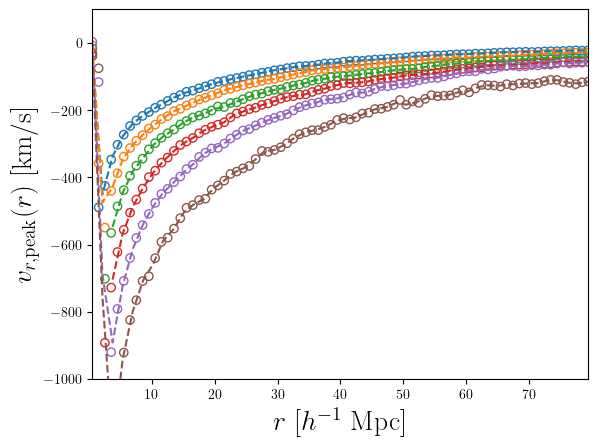

In [9]:
from scipy.interpolate import interp1d 

# vr_pars = np.zeros((len(Mvirs), 2))
# vr_errs = np.zeros((len(Mvirs), 2))

interps = []
m_interps = []

for k in range(len(Mvirs)):
    #plt.scatter(rlos_cens, peak_vr_r[k], color=f'C{k}')


    plt.scatter(r_cens_LS, peak_vr_r[k], edgecolors=f'C{k}', marker='o', facecolors='none')

    interp = interp1d(r_cens_LS, peak_vr_r[k], kind='slinear', bounds_error=False, fill_value='extrapolate')
    m_interp = interp1d(r_cens_LS, mean_vr_r[k], kind='slinear', bounds_error=False, fill_value='extrapolate')

    interps.append(interp)
    m_interps.append(m_interp)

    mask = (r_cens_LS > 5) & (~np.isnan(peak_vr_r[k]))

    #p, c = curve_fit(plawc, r_cens_LS[mask]/20, peak_vr_r[k][mask], maxfev=2_000)
    #vr_pars[k] = p
    #vr_errs[k] = np.sqrt(np.diag(c))

    rloss = np.linspace(r_cens_LS.min(), r_cens_LS.max())

    #plt.plot(rloss, plawc(rloss/20, p[0], p[1], p[2]))
    plt.plot(rloss, interp(rloss), color=f'C{k}', ls='--')


    plt.ylim((-1000, 100))
    #plt.ylim((-100, 1000))
    plt.margins(x=0)
    plt.ylabel(r"$v_{r, \rm peak}(r)$ [km/s]", fontsize=20)
    plt.xlabel(r"$r \ [h^{-1}$ Mpc]", fontsize=20)

In [10]:
# Fit gaussian fcns to P(v|r, rlos), 1: totally free, 2. Fix <vlos> to vrpk*sin\theta + aHrlos

Gpars = np.zeros((len(Mvirs), len(r_cens), len(rlos_cens), 2))
Gerrs = np.zeros(Gpars.shape)

Gfixpars = np.zeros((len(Mvirs), len(r_cens), len(rlos_cens), 2))
Gfixerrs = np.zeros(Gfixpars.shape)

peaks = np.zeros((len(Mvirs), len(r_cens), len(rlos_cens)))

for k in range(len(Mvirs)):
    for j in range(len(r_cens)):
        for i in range(len(rlos_cens)):
            index = i + j*len(rlos_cens) + k*len(r_cens)*len(rlos_cens)

            r = np.sqrt(r_cens[j]**2 + rlos_cens[i]**2)
            theta = np.arctan2(rlos_cens[i], r_cens[j])
            sin = np.sin(theta)

            peak = interps[k](r)*sin #+ a*H*rlos_cens[i]/h

            ve = np.linspace(peak-2500, peak+2500, 50+1)
            vc = 0.5*(ve[1:] + ve[:-1])

            hist, edges = np.histogram(vpeclos1[index], bins=ve, density=True)
            cent = 0.5*(edges[1:] + edges[:-1])

            if np.isnan(hist).any():
                break
            else:

                p, c = curve_fit(norm.pdf, cent, hist, p0=[peak, 400])
                
                Gpars[k, j, i] = p
                Gerrs[k, j, i] = np.sqrt(np.diag(c))

                p, c = curve_fit(lambda x, s: norm.pdf(x, loc=peak, scale=s), cent, hist, p0=400)
                
                Gfixpars[k, j, i] = p
                Gfixerrs[k, j, i] = np.sqrt(np.diag(c))

                peaks[k, j, i] = peak

In [11]:
# fit using edgeworth expansion

from scipy.special import eval_hermite

def gam2_EW(x, mu, sigma, gam1, gam2):
    
    z = ( x - mu ) / sigma # scaled input

    H3 = eval_hermite(3, z)
    H4 = eval_hermite(4, z) 
    H6 = eval_hermite(6, z)

    prefac = norm.pdf(z) / sigma

    brackets = 1 + gam1*H3/6 + gam2*H4/24 + gam1**2*H6/72

    return prefac*brackets    

EWpars = np.zeros((len(Mvirs), len(r_cens), len(rlos_cens), 4))
EWerrs = np.zeros(EWpars.shape)


for k in range(len(Mvirs)):
    for j in range(len(r_cens)):
        for i in range(len(rlos_cens)):
            index = i + j*len(rlos_cens) + (k)*len(r_cens)*len(rlos_cens)

            r = np.sqrt(r_cens[j]**2 + rlos_cens[i]**2)
            theta = np.arctan2(rlos_cens[i], r_cens[j])
            sin = np.sin(theta)


            peak = interps[k](r)*sin #+ a*H*rlos_cens[i]/h

            ve = np.linspace(peak-2500, peak+2500, 50+1)
            vc = 0.5*(ve[1:] + ve[:-1])

            hist, edges = np.histogram(vpeclos1[index], bins=ve, density=True)
            cent = 0.5*(edges[1:] + edges[:-1])

            if np.isnan(hist).any():
                break
            else:

                p, c = curve_fit(gam2_EW, cent, hist, p0=[peak, 400, 0.1, 0.1], maxfev=5_000)
                
                EWpars[k, j, i] = p
                EWerrs[k, j, i] = np.sqrt(np.diag(c))

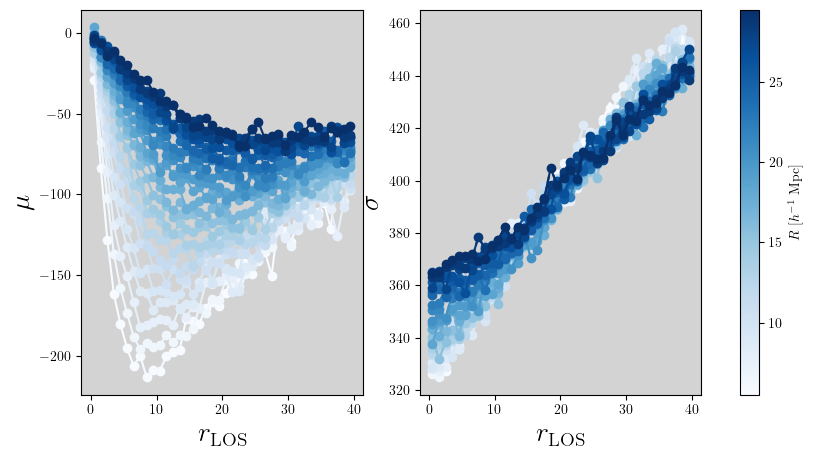

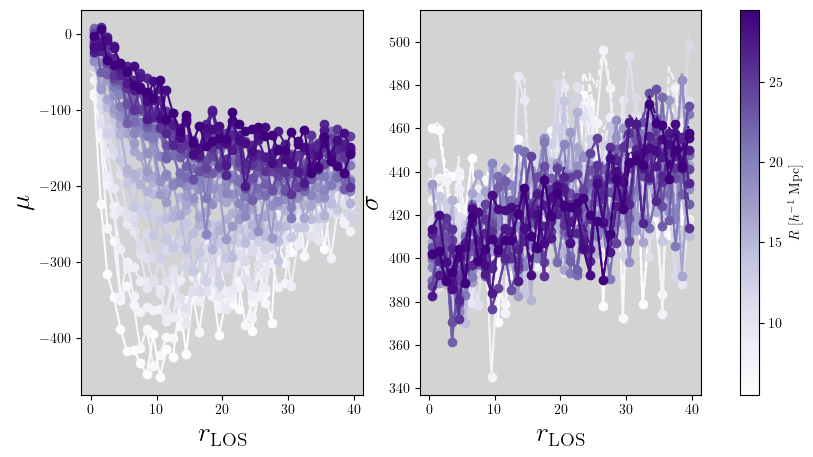

In [12]:
# analyze dependences
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

colormap_list = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, 
                 plt.cm.Reds, plt.cm.Purples, plt.cm.Greys]

cmaps = [cmap(np.linspace(0, 1, len(r_cens))) for cmap in colormap_list]


for k in range(0, len(Mvirs), len(Mvirs)-2):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    for j in range(len(r_cens)):
        ax[0].plot(rlos_cens, Gpars[k, j, :, 0], c=cmaps[k][j], marker='o')
        ax[0].set_xlabel(r"$r_{\rm LOS}$", fontsize=20)
        ax[0].set_ylabel(r"$\mu$", fontsize=20)

        ax[1].plot(rlos_cens, Gpars[k, j, :, 1], c=cmaps[k][j], marker='o')
        ax[1].plot(rlos_cens, Gfixpars[k, j, :, 0], c=cmaps[k][j], ls='--')
        ax[1].set_xlabel(r"$r_{\rm LOS}$", fontsize=20)
        ax[1].set_ylabel(r"$\sigma$", fontsize=20)

    ax[0].set_facecolor('lightgray')
    ax[1].set_facecolor('lightgray')
    
    Norm = Normalize(vmin=min(r_cens), vmax=max(r_cens))
    sm = ScalarMappable(norm=Norm, cmap=colormap_list[k])
    sm.set_array([])  # dummy array
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r"$R \ [h^{-1}$ Mpc]")

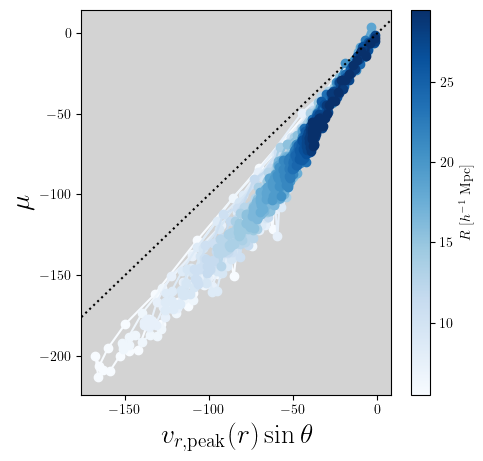

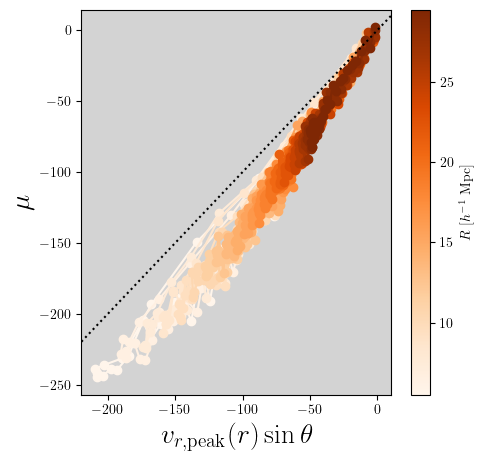

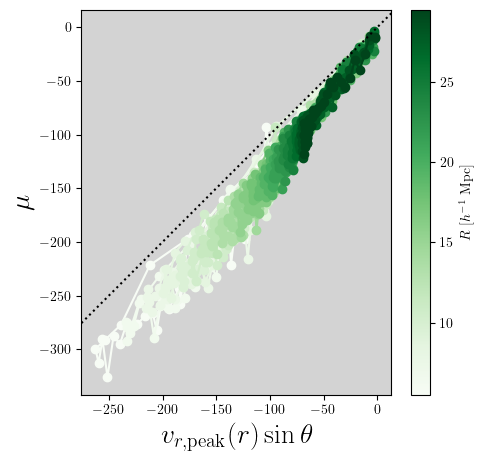

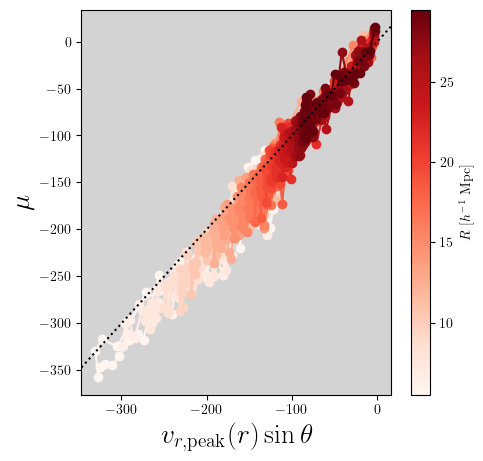

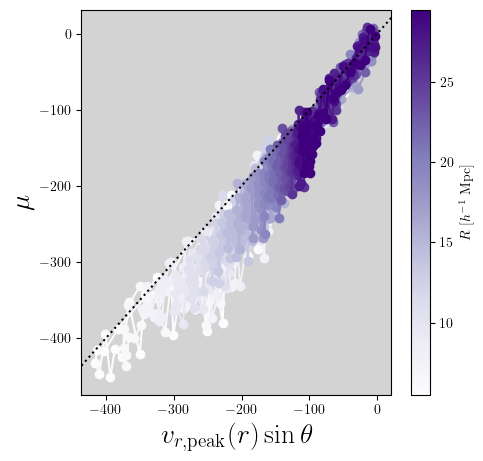

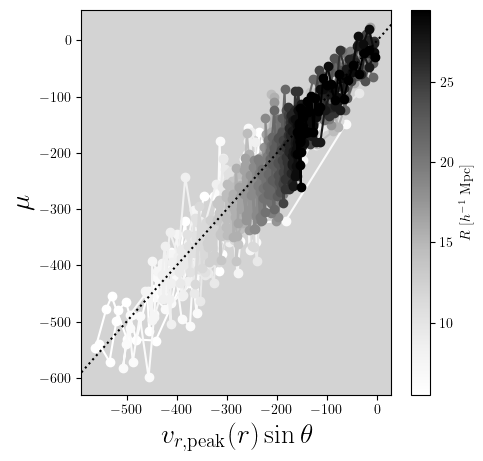

In [13]:
# how does BF \mu relate to peak?

for k in range(0, len(Mvirs)):
    fig, ax = plt.subplots(1, figsize=(5, 5))
    for j in range(len(r_cens)):
        mask = rlos_cens < 40
        ax.plot(peaks[k, j][mask], Gpars[k, j, :, 0][mask], c=cmaps[k][j], marker='o')
        ax.set_xlabel(r"$v_{r, \rm peak}(r)\sin\theta$", fontsize=20)
        ax.set_ylabel(r"$\mu$", fontsize=20)


    ax.axline((0, 0), slope=1, ls=':', c='k')
    ax.set_facecolor('lightgray')
    
    Norm = Normalize(vmin=min(r_cens), vmax=max(r_cens))
    sm = ScalarMappable(norm=Norm, cmap=colormap_list[k])
    sm.set_array([])  # dummy array
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r"$R \ [h^{-1}$ Mpc]")

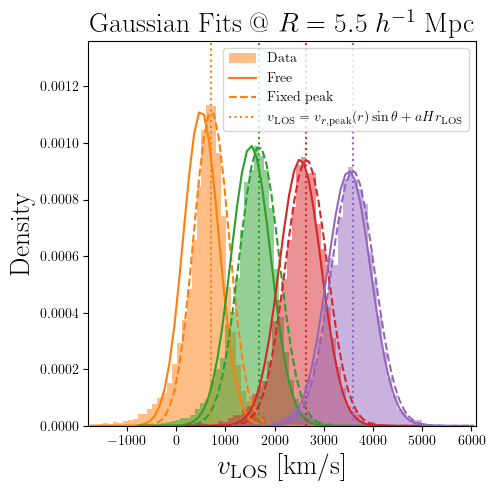

In [14]:
# test fit to P(vlos|R, rlos)
i, j, k = 10, 0, 0

rlos_inds = [9, 19, 29, 39]

plt.figure(figsize=(5, 5))

for i in rlos_inds:
    index = i + j*len(rlos_cens) + (k//5)*len(r_cens)*len(rlos_cens)

    r = np.sqrt(r_cens[j]**2 + rlos_cens[i]**2)
    theta = np.arctan2(rlos_cens[i], r_cens[j])
    sin = np.sin(theta)


    peak = interps[k](r)*sin + a*H*rlos_cens[i]/h

    ve = np.linspace(peak-2500, peak+2500, 50+1)
    vc = 0.5*(ve[1:] + ve[:-1])

    hist, edges = np.histogram(vphyslos1[index], bins=ve, density=True)
    cent = 0.5*(edges[1:] + edges[:-1])

   

    test_hist, bins, _ = plt.hist(vphyslos1[i + j*len(rlos_cens) + k*len(r_cens)*len(rlos_cens)], bins=ve, density=True, alpha=0.5, label='Data', color=f'C{i//9}')
    cens = 0.5*(bins[1:] + bins[:-1])

    #plt.plot(cens, P_R_rlos_test(cens, r_cens[j], rlos_cens[i], Mvirs[k], p))
    plt.plot(cens, norm.pdf(cens-peak, loc=Gpars[k, j, i, 0], scale=Gpars[k, j, i, 1]), c=f'C{i//9}', label='Free')
    plt.plot(cens, norm.pdf(cens, loc=peak, scale=Gfixpars[k, j, i, 1]), c=f'C{i//9}', ls='--', label='Fixed peak')

    plt.axvline(peak, label=r"$v_{\rm LOS} = v_{r, \rm peak}(r)\sin\theta + aHr_{\rm LOS}$", color=f'C{i//9}', ls=':')

    plt.title(rf"Gaussian Fits @ $R = {r_cens[j]}$ $h^{{-1}}$ Mpc ", fontsize=20)
    plt.xlabel(r"$v_{\rm LOS}$ [km/s]", fontsize=20)
    plt.ylabel(r"Density", fontsize=20)
    plt.margins(x=0) 

    if i == rlos_inds[0]:
        plt.legend()
        plt.ylim((0, 1.2*np.max(hist)))

5.533868009037994e-19
7.422964110448352e-26
6.576284521404481e-34
3.566762995992814e-41


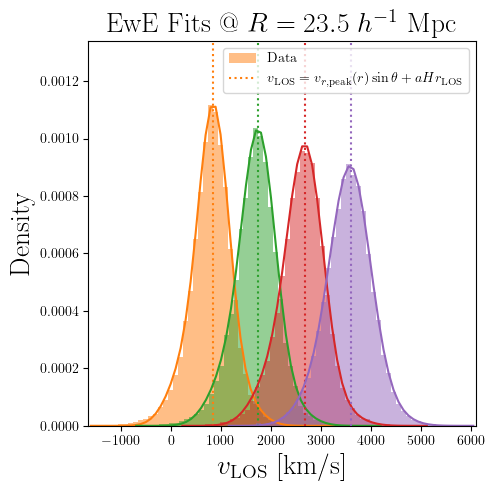

In [16]:
# test fit to P(vlos|R, rlos)
i, j, k = 10, 18, 0

rlos_inds = [9, 19, 29, 39]

plt.figure(figsize=(5, 5))

for i in rlos_inds:
    index = i + j*len(rlos_cens) + (k//5)*len(r_cens)*len(rlos_cens)

    r = np.sqrt(r_cens[j]**2 + rlos_cens[i]**2)
    theta = np.arctan2(rlos_cens[i], r_cens[j])
    sin = np.sin(theta)


    peak = interps[k](r)*sin + a*H*rlos_cens[i]/h

    ve = np.linspace(peak-2500, peak+2500, 50+1)
    vc = 0.5*(ve[1:] + ve[:-1])

    hist, edges = np.histogram(vphyslos1[index], bins=ve, density=True)
    cent = 0.5*(edges[1:] + edges[:-1])

   

    test_hist, bins, _ = plt.hist(vphyslos1[i + j*len(rlos_cens) + k*len(r_cens)*len(rlos_cens)], bins=ve, density=True, alpha=0.5, label='Data', color=f'C{i//9}')
    cens = 0.5*(bins[1:] + bins[:-1])

    print(np.min(gam2_EW(cens, EWpars[k, j, i, 0], EWpars[k, j, i, 1], EWpars[k, j, i, 2], EWpars[k, j, i, 3])))
    plt.plot(cens, gam2_EW(cens-a*H*rlos_cens[i]/h, EWpars[k, j, i, 0], EWpars[k, j, i, 1], EWpars[k, j, i, 2], EWpars[k, j, i, 3]), c=f'C{i//9}')

    plt.axvline(peak, label=r"$v_{\rm LOS} = v_{r, \rm peak}(r)\sin\theta + aHr_{\rm LOS}$", color=f'C{i//9}', ls=':')

    plt.title(rf"EwE Fits @ $R = {r_cens[j]}$ $h^{{-1}}$ Mpc ", fontsize=20)
    plt.xlabel(r"$v_{\rm LOS}$ [km/s]", fontsize=20)
    plt.ylabel(r"Density", fontsize=20)
    plt.margins(x=0) 

    if i == rlos_inds[0]:
        plt.legend()
        plt.ylim((0, 1.2*np.max(hist)))

In [17]:
def P_R_ind_free(vlos, R_ind, M_ind):
    R = r_cens[R_ind]
    M = Mvirs[M_ind]

    rho_g = 0.014  # h^3 Mpc^-3 mean galaxy number density in MDPL2

    rlos_con = np.concatenate((-np.flip(rlos_cens), rlos_cens))

    r3d = np.sqrt(R**2 + rlos_cens**2)
    weight = rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1)  

    Pvlos_interp_list = []

    for j in range(len(rlos_cens)):
        r = np.sqrt(R**2 + rlos_cens[j]**2)
        theta = np.arctan2(rlos_cens[j], R)
        sin = np.sin(theta)

        peak = interps[M_ind](r)*sin + a*H*rlos_cens[j]/h
        ve = np.linspace(peak - 2500, peak + 2500, 100+1)
        vc = 0.5*(ve[1:] + ve[:-1])

        Pvlos = norm.pdf(vc - a*H*rlos_cens[j]/h, loc=Gpars[M_ind, R_ind, j, 0], scale=Gpars[M_ind, R_ind, j, 1])

        interp_func = interp1d(
            vc, Pvlos, kind="linear", bounds_error=False, fill_value=0.0
        )
        interpolated = interp_func(vlos[:, None])

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list).reshape(len(rlos_cens), len(vlos))
    Pvlos_interp = Pvlos_interp.T

    integrand = Pvlos_interp * weight[None, :] 

    integrand = np.concatenate((np.flip(integrand, axis=(0, 1)), integrand), axis=1)

    P_out = simpson(integrand, x=rlos_con, axis=1)

    return P_out / np.sum(P_out * np.diff(vlos)[0]) 

def P_R_ind_fix(vlos, R_ind, M_ind):
    R = r_cens[R_ind]
    M = Mvirs[M_ind]

    rho_g = 0.014  # h^3 Mpc^-3 mean galaxy number density in MDPL2

    rlos_con = np.concatenate((-np.flip(rlos_cens), rlos_cens))

    r3d = np.sqrt(R**2 + rlos_cens**2)
    weight = rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1)  

    Pvlos_interp_list = []

    for i in range(len(rlos_cens)):
        r = np.sqrt(R**2 + rlos_cens[i]**2)
        theta = np.arctan2(rlos_cens[i], R)
        sin = np.sin(theta)

        peak = interps[M_ind](r)*sin + a*H*rlos_cens[i]/h
        ve = np.linspace(peak - 2500, peak + 2500, 100+1)
        vc = 0.5*(ve[1:] + ve[:-1])

        Pvlos = norm.pdf(vc, loc=peak, scale=Gfixpars[M_ind, R_ind, i, 1])

        interp_func = interp1d(
            vc, Pvlos, kind="linear", bounds_error=False, fill_value=0.0
        )
        interpolated = interp_func(vlos[:, None])

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list).reshape(len(rlos_cens), len(vlos))
    Pvlos_interp = Pvlos_interp.T

    integrand = Pvlos_interp * weight[None, :] 

    integrand = np.concatenate((np.flip(integrand, axis=(0, 1)), integrand), axis=1)

    P_out = simpson(integrand, x=rlos_con, axis=1)

    return P_out / np.sum(P_out * np.diff(vlos)[0]) 

def P_R_ind_EW(vlos, R_ind, M_ind):
    R = r_cens[R_ind]
    M = Mvirs[M_ind]

    rho_g = 0.014  # h^3 Mpc^-3 mean galaxy number density in MDPL2

    rlos_con = np.concatenate((-np.flip(rlos_cens), rlos_cens))


    Pvlos_interp_list = []

    for i in range(len(rlos_cens)):
        r = np.sqrt(R**2 + rlos_cens[i]**2)
        theta = np.arctan2(rlos_cens[i], R)
        sin = np.sin(theta)

        peak = interps[M_ind](r)*sin + a*H*rlos_cens[i]/h
        ve = np.linspace(peak - 2500, peak + 2500, 100+1)
        vc = 0.5*(ve[1:] + ve[:-1])

        Pvlos = gam2_EW(vc-a*H*rlos_cens[i]/h, EWpars[M_ind, R_ind, i, 0], EWpars[M_ind, R_ind, i, 1], EWpars[M_ind, R_ind, i, 2], EWpars[M_ind, R_ind, i, 3])#norm.pdf(vc, loc=peak, scale=Gfixpars[M_ind, R_ind, i, 1])

        interp_func = interp1d(
            vc, Pvlos, kind="cubic", bounds_error=False, fill_value=0.0
        )
        interpolated = interp_func(vlos[:, None])

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list).reshape(len(rlos_cens), len(vlos))
    Pvlos_interp = Pvlos_interp.T

    rlos_fine = np.linspace(rlos_cens[0], rlos_cens[-1]+20, 500)
    rlos_con_fine = np.concatenate((-np.flip(rlos_fine), rlos_fine))#np.linspace(rlos_con[0], rlos_con[-1], 200)

    r3d = np.sqrt(R**2 + rlos_fine**2)
    weight = rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1)  

    Pvlos_interp2 = interp1d(rlos_cens, Pvlos_interp, kind='linear', axis=1, bounds_error=False, fill_value=0.0)(rlos_fine)

    integrand = Pvlos_interp2 * weight[None, :] 

    integrand = np.concatenate((np.flip(integrand, axis=(0, 1)), integrand), axis=1)

    #print(integrand.shape, Pvlos_interp.shape, Pvlos_interp2.shape, weight.shape, rlos_con_fine.shape)

    P_out = simpson(integrand, x=rlos_con_fine, axis=1)

    return P_out / np.sum(P_out * np.diff(vlos)[0])

In [44]:
r_cens[18]

np.float64(23.5)

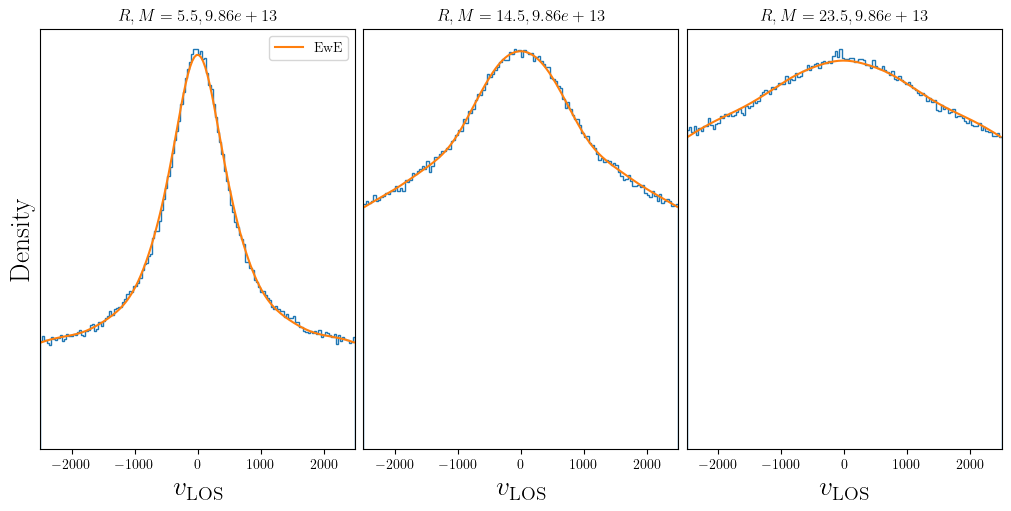

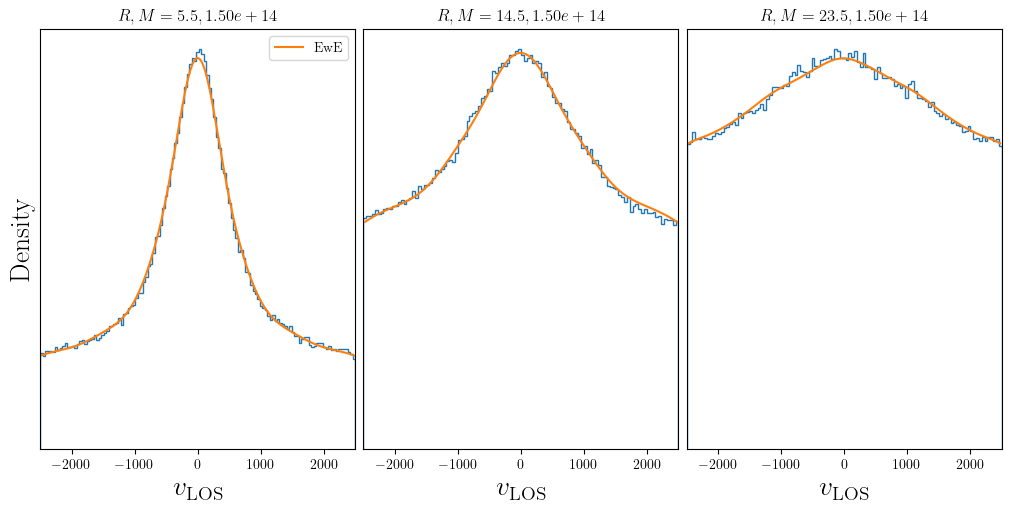

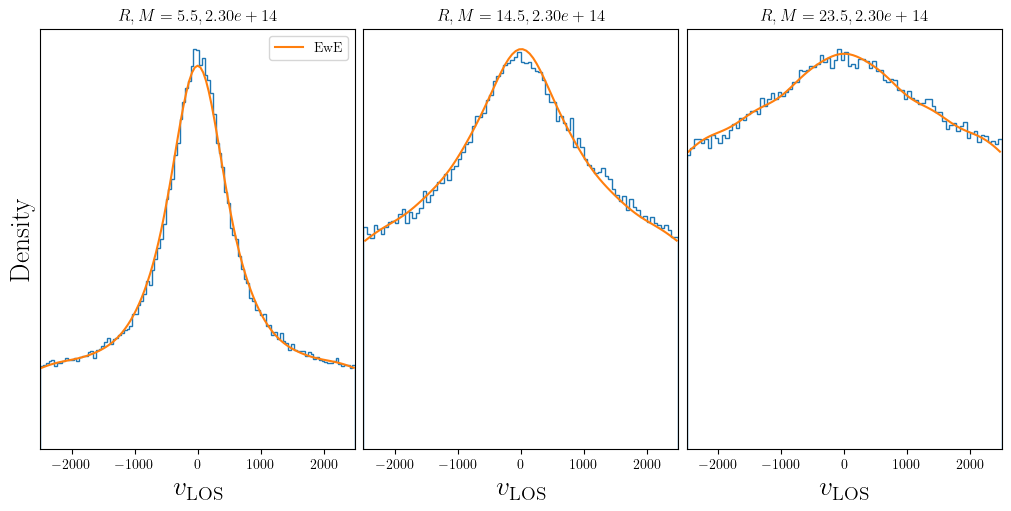

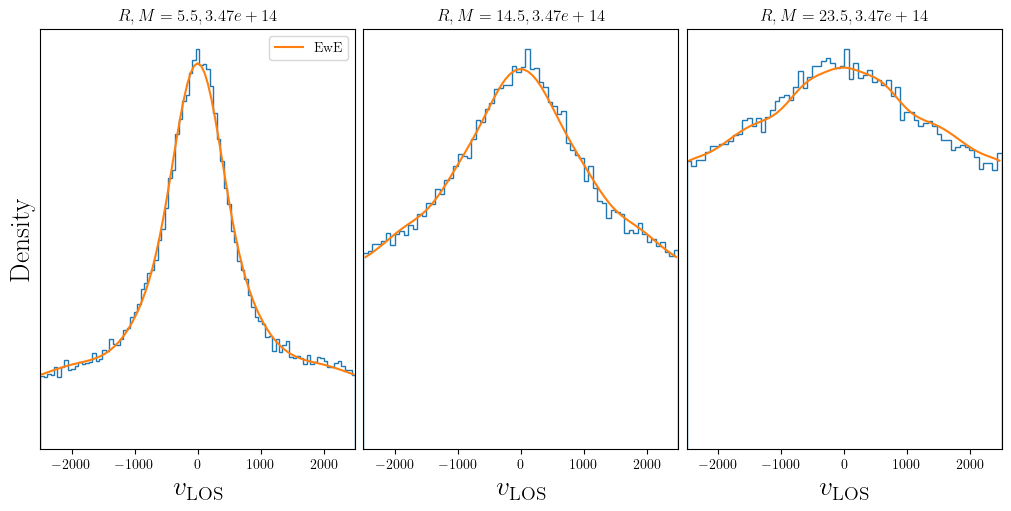

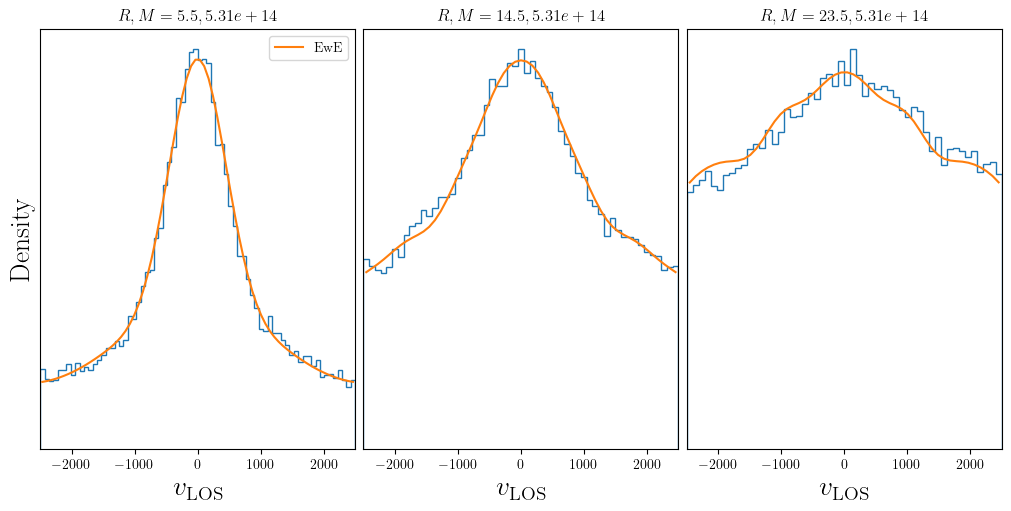

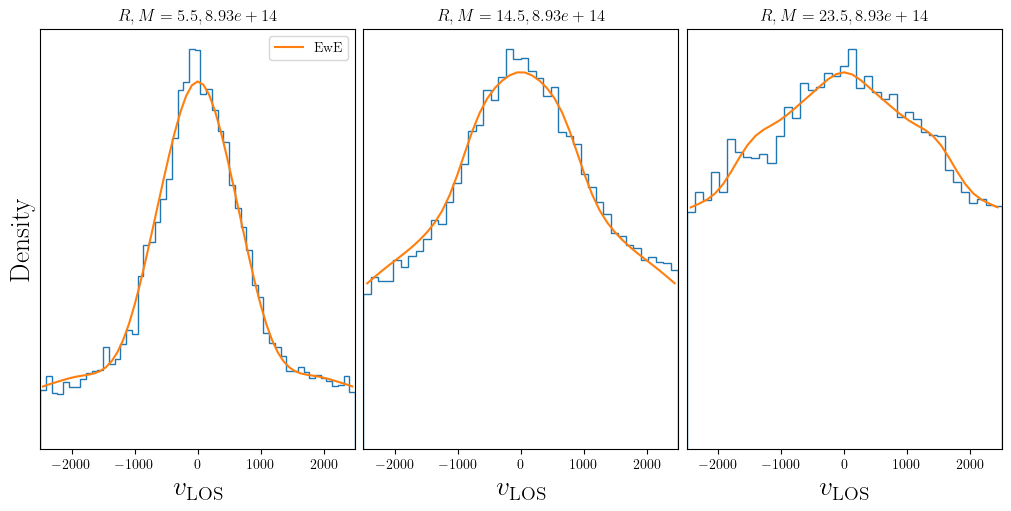

In [18]:
j, k = 0, 0

for k in range(len(Mvirs)):
    fig, ax = plt.subplots(1, len(r_cens)//7, figsize=(10, 5), layout='constrained')
    for j in range(0, len(r_cens), 9):
        index = j + k*len(r_cens)

        hist, bins, _ = ax[j//7].hist(vphyslos[index], range=[-2500, 2500], bins='auto', density=True, histtype='step')
        cent = 0.5*(bins[1:] + bins[:-1])

        # ax[j//7].plot(cent, P_R_ind_free(cent, j, k), label='Free', c='C1')
        # ax[j//7].plot(cent, P_R_ind_fix(cent, j, k), label='Fixed peak', ls='--', c='C1')

        ax[j//7].plot(cent, P_R_ind_EW(cent, j, k), label='EwE', c='C1')


        ax[j//7].set_xlabel(r"$v_{\rm LOS}$", fontsize=20)
        ax[j//7].set_yticks([])
        ax[j//7].margins(x=0)
        ax[j//7].set_title(rf"$R, M = {r_cens[j]}, {Mvirs[k]:.2e}$")

    ax[0].legend()
    ax[0].set_ylabel(r"Density", fontsize=20)


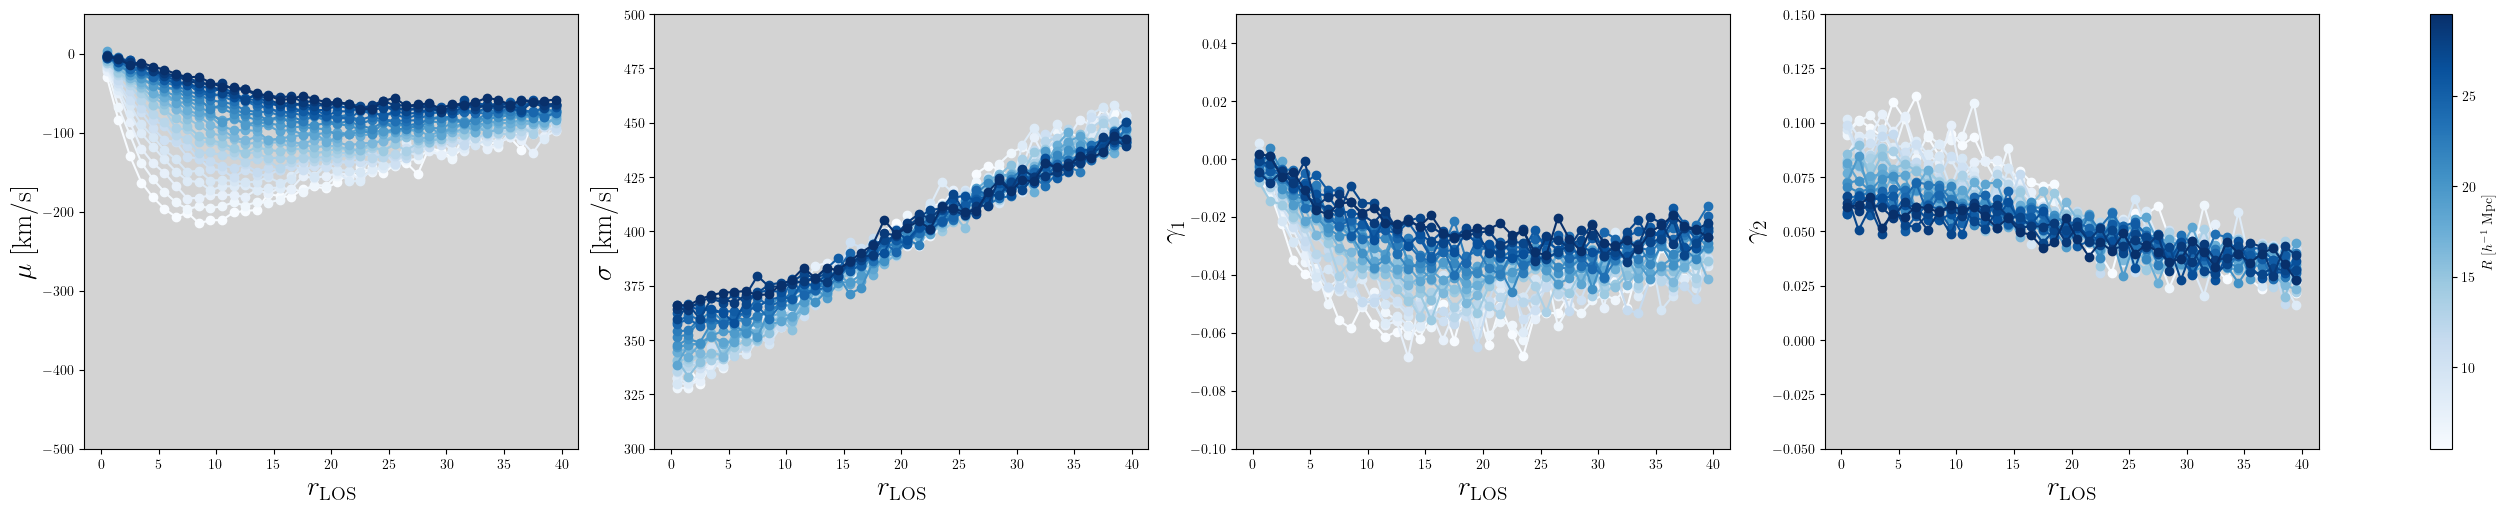

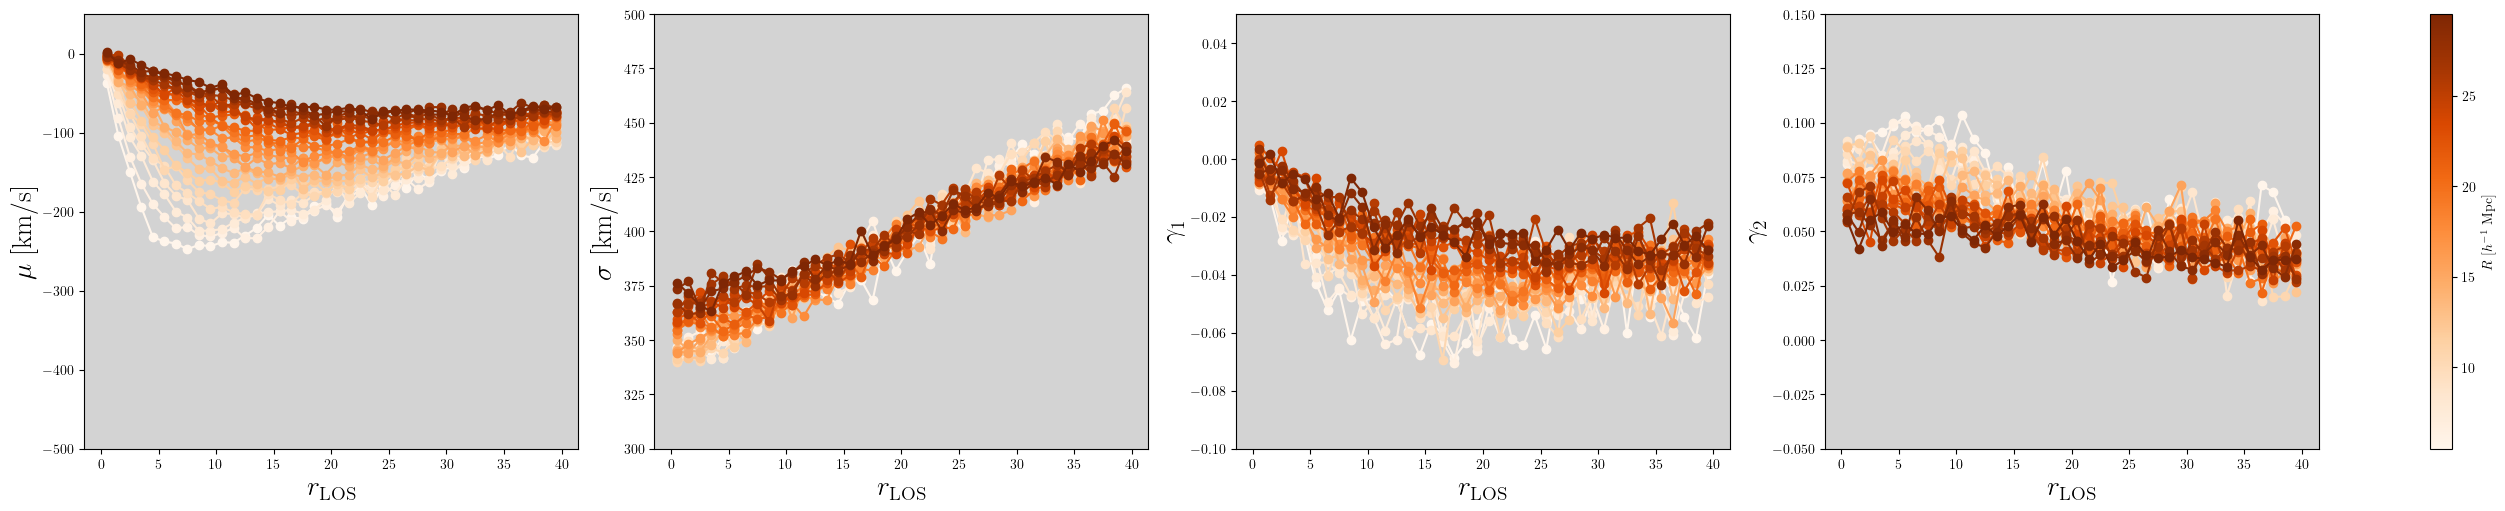

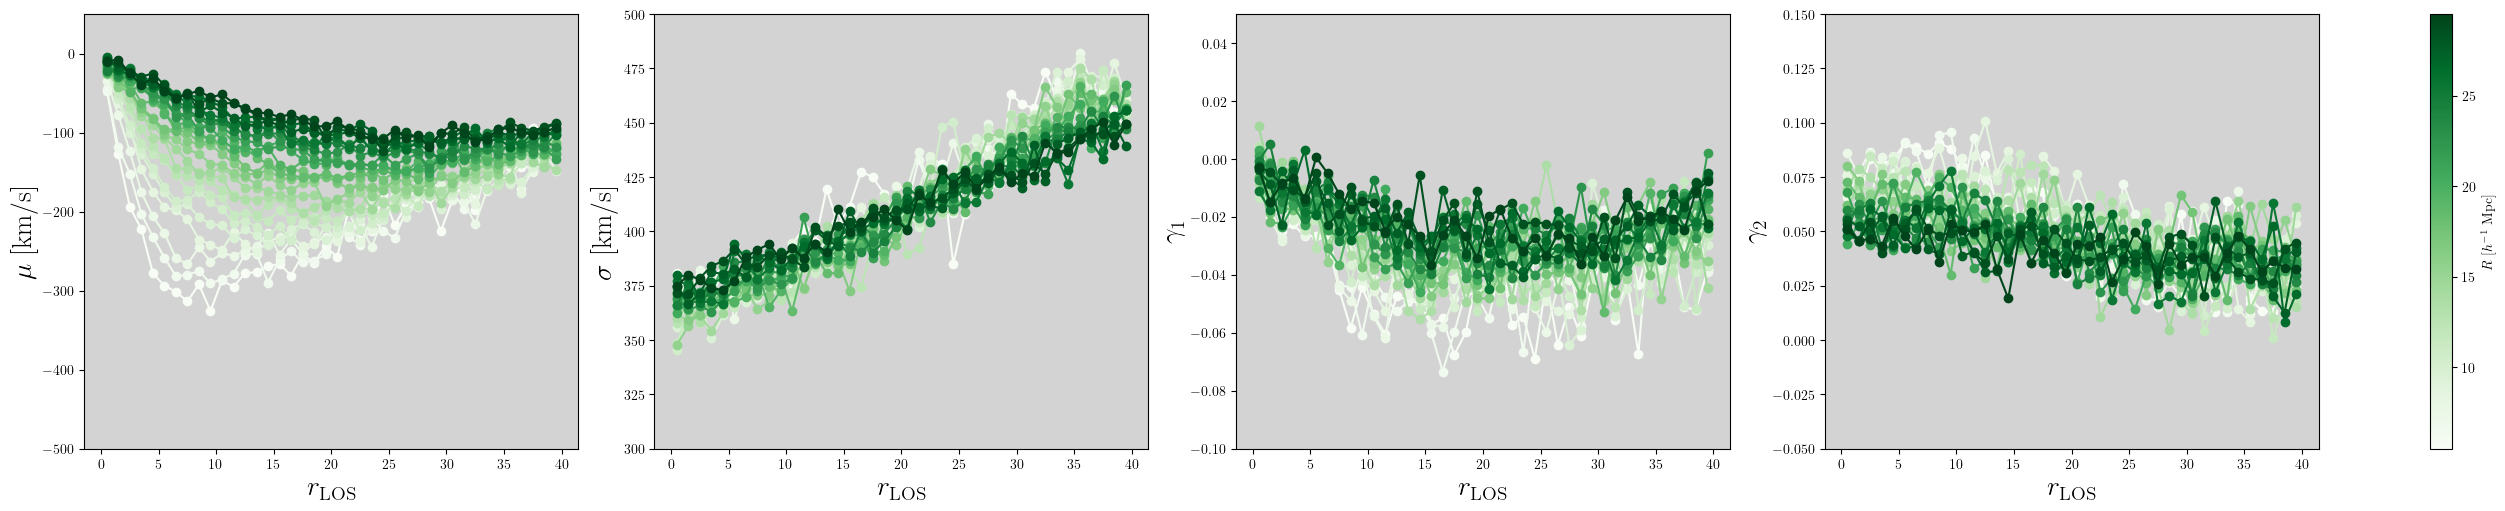

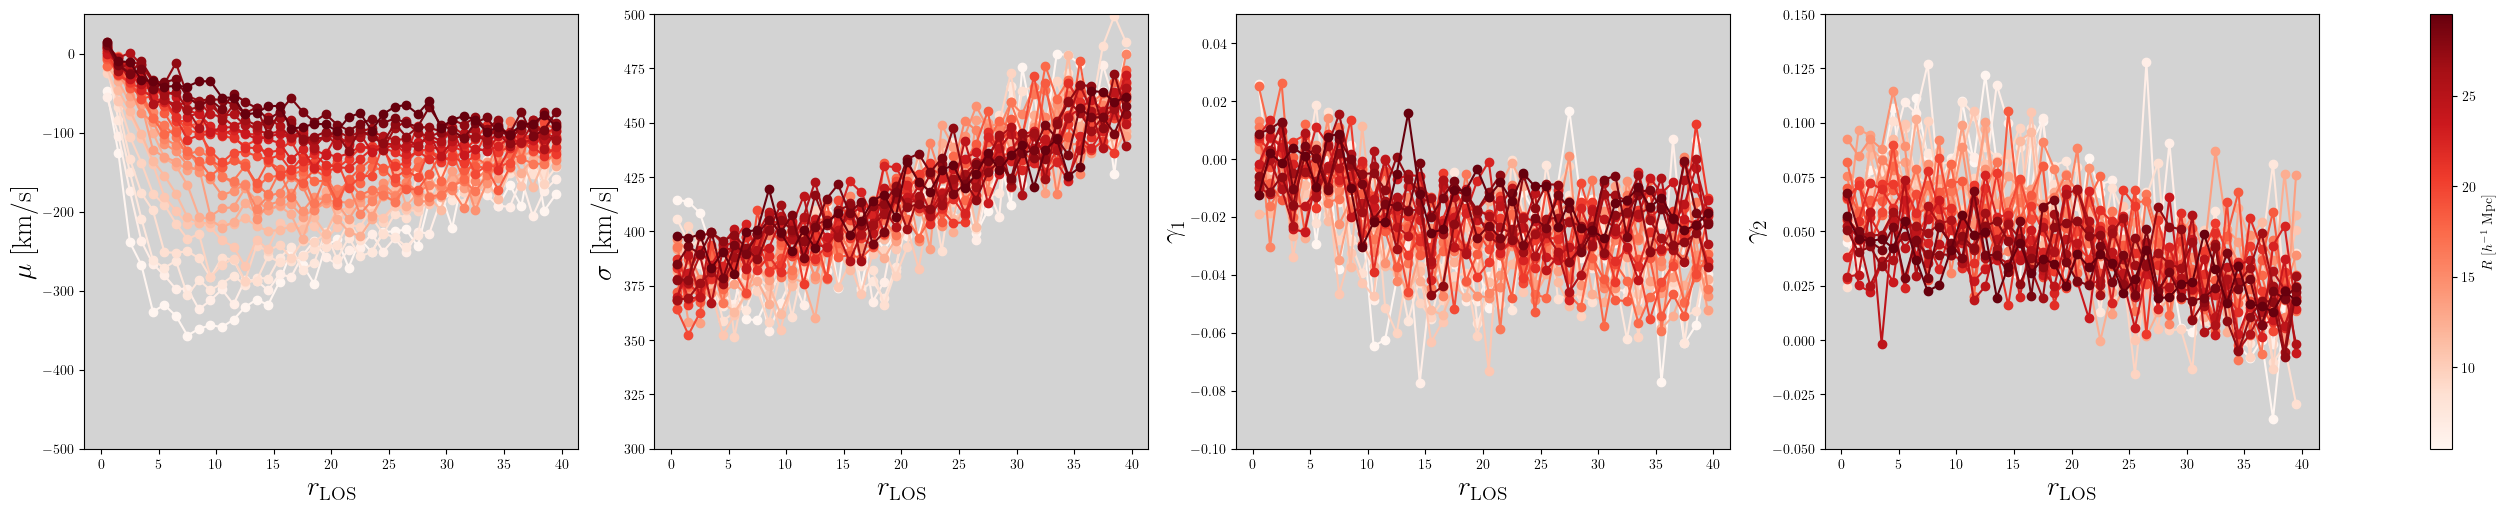

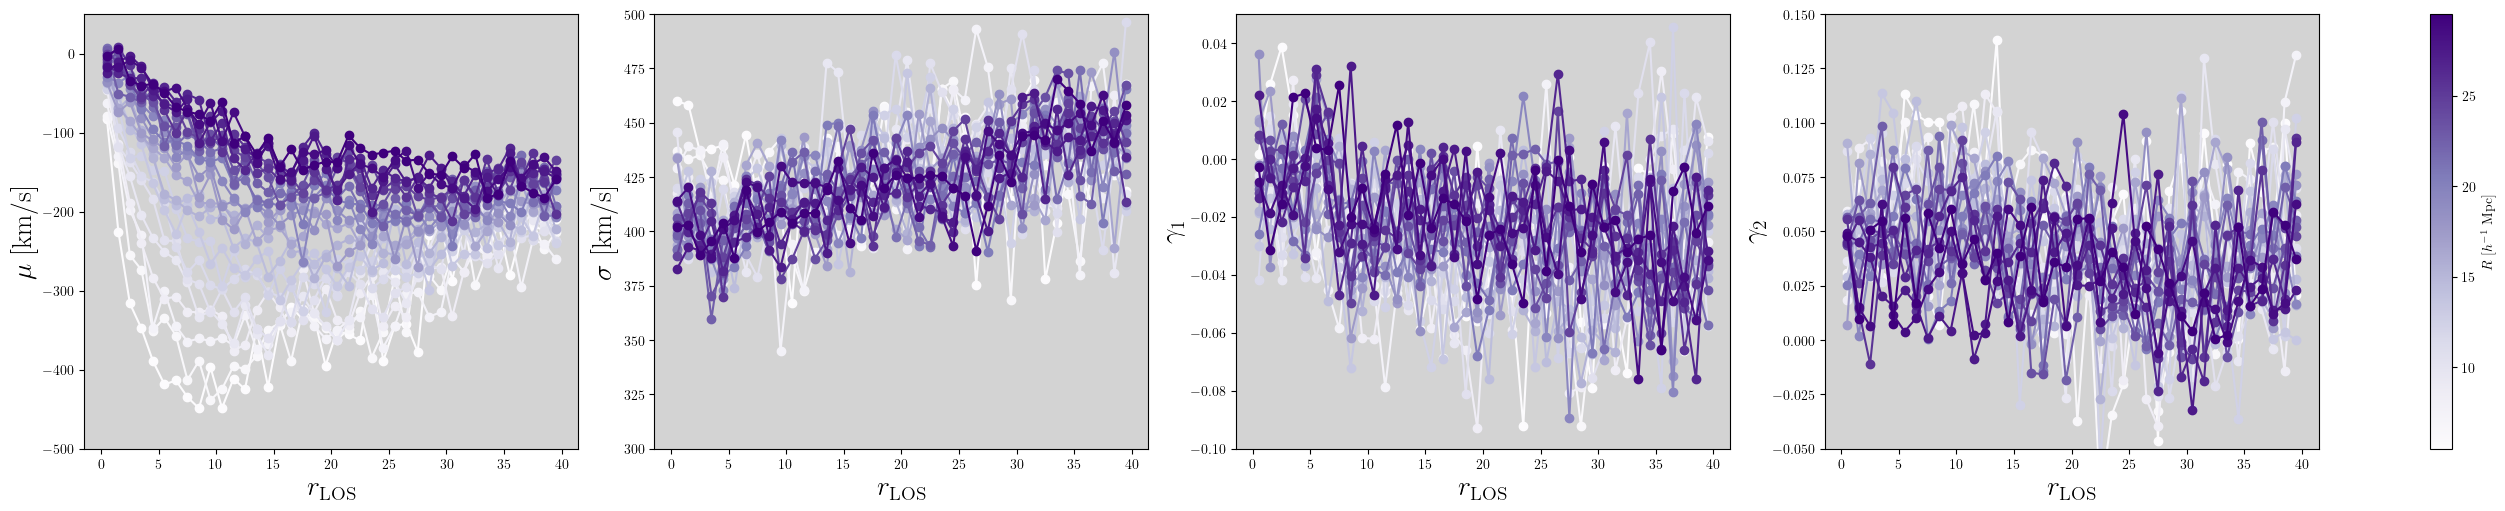

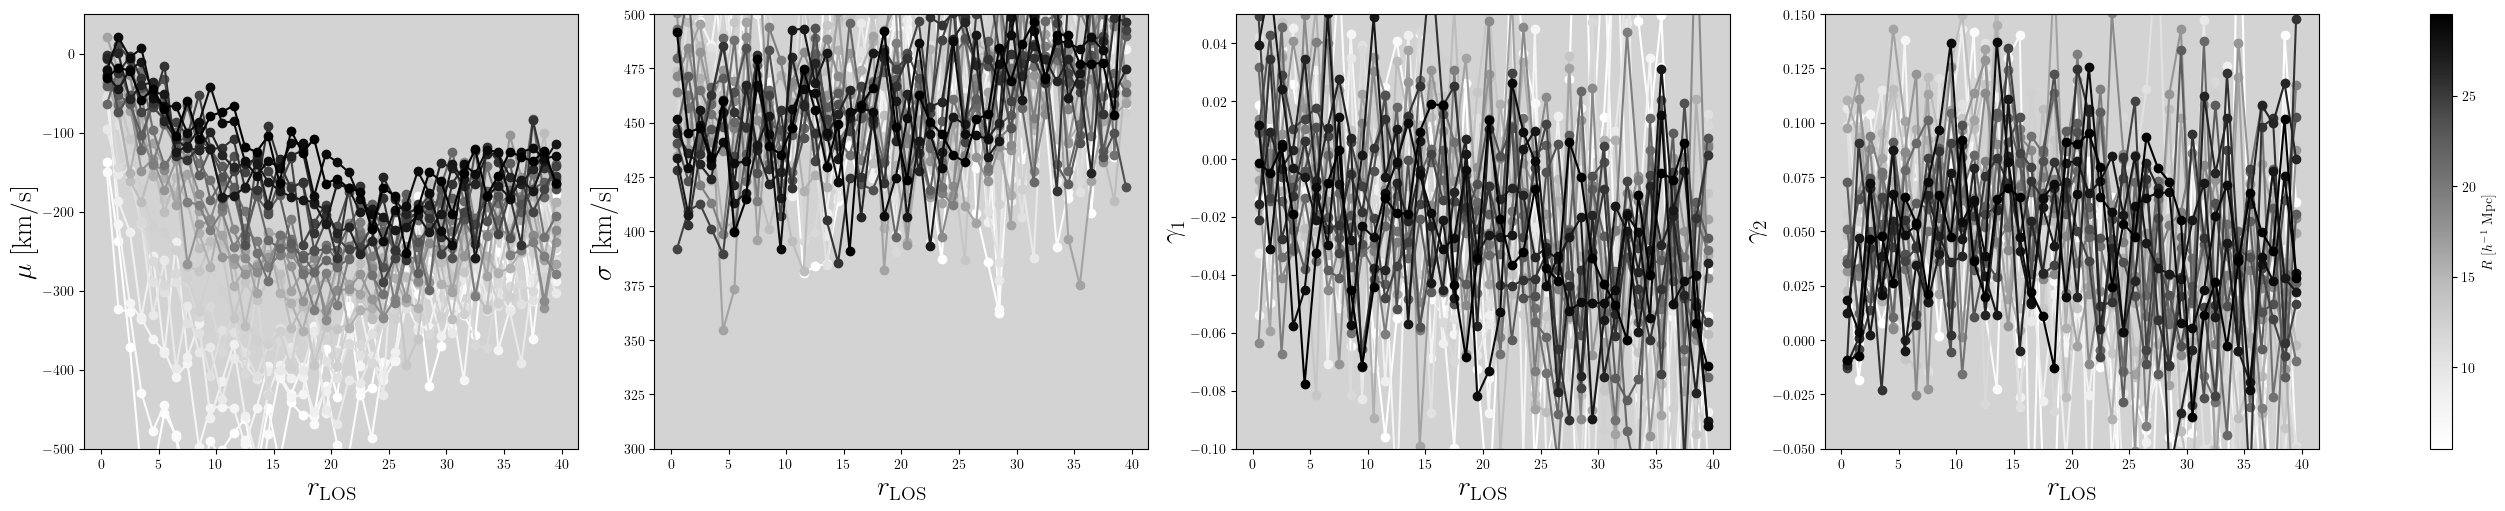

In [19]:
# look at EwE dependence


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

colormap_list = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, 
                 plt.cm.Reds, plt.cm.Purples, plt.cm.Greys]

cmaps = [cmap(np.linspace(0, 1, len(r_cens))) for cmap in colormap_list]

names = [r'$\mu$ [km/s]', r'$\sigma$ [km/s]', r'$\gamma_1$', r'$\gamma_2$']

lims = [(-500, 50), (300, 500), (-0.1, 0.05), (-0.05, 0.15)]

for k in range(0, len(Mvirs)):
    fig, ax = plt.subplots(1, 4, figsize=(25, 5), layout='constrained')
    for j in range(len(r_cens)):
        for i in range(len(names)):
            ax[i].plot(rlos_cens, EWpars[k, j, :, i], c=cmaps[k][j], marker='o')
            ax[i].set_xlabel(r"$r_{\rm LOS}$", fontsize=20)
            ax[i].set_ylabel(names[i], fontsize=20)
            ax[i].set_ylim(lims[i])

            ax[i].set_facecolor('lightgray')
    
    Norm = Normalize(vmin=min(r_cens), vmax=max(r_cens))
    sm = ScalarMappable(norm=Norm, cmap=colormap_list[k])
    sm.set_array([])  # dummy array
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r"$R \ [h^{-1}$ Mpc]")


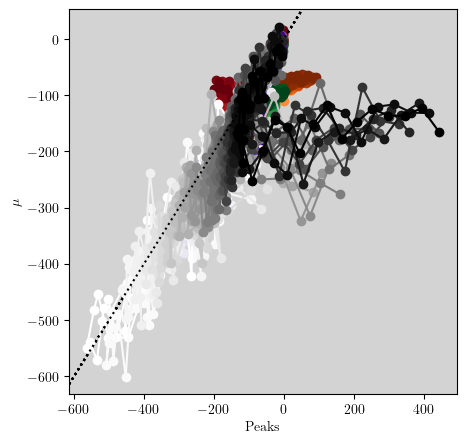

In [189]:
# how does BF \mu relate to peak?
fig, ax = plt.subplots(1, figsize=(5, 5))

for k in range(0, len(Mvirs)):
    for j in range(len(r_cens)):
        ax.plot(peaks[k, j], EWpars[k, j, :, 0], c=cmaps[k][j], marker='o')
        ax.set_xlabel(r"Peaks")
        ax.set_ylabel(r"$\mu$")


    ax.axline((0, 0), slope=1, ls=':', c='k')
    ax.set_facecolor('lightgray')
    
    # Norm = Normalize(vmin=min(r_cens), vmax=max(r_cens))
    # sm = ScalarMappable(norm=Norm, cmap=colormap_list[k])
    # sm.set_array([])  # dummy array
    # cbar = fig.colorbar(sm, ax=ax)
    # cbar.set_label(r"$R \ [h^{-1}$ Mpc]")

In [23]:
EWpars[k, j, :].shape

(40, 4)

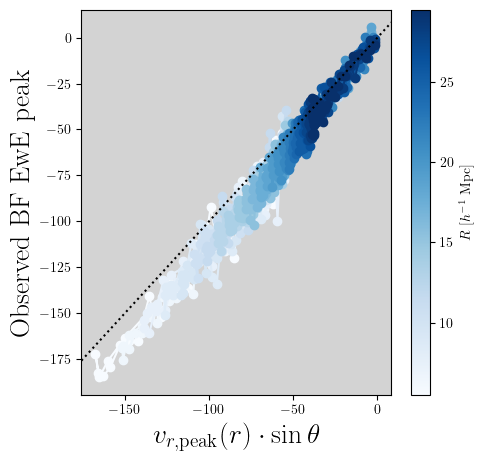

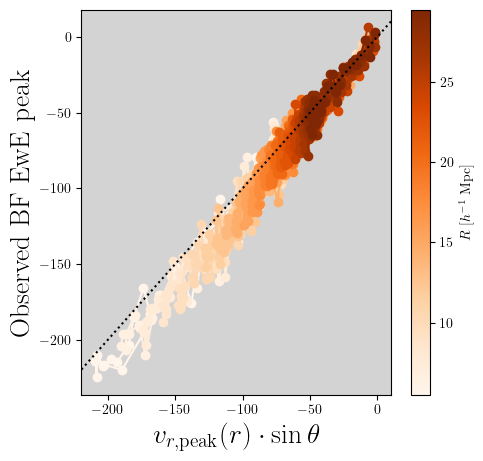

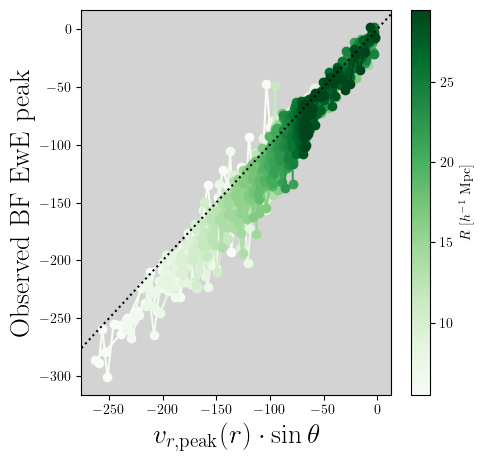

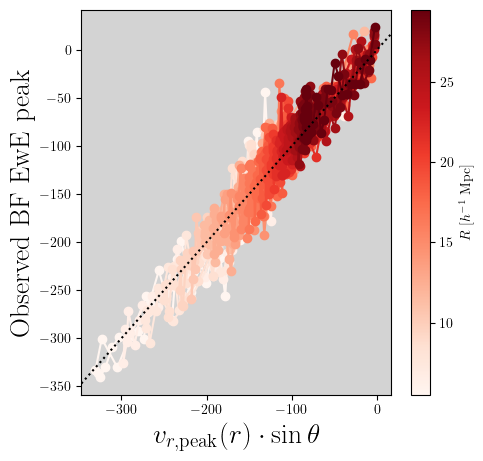

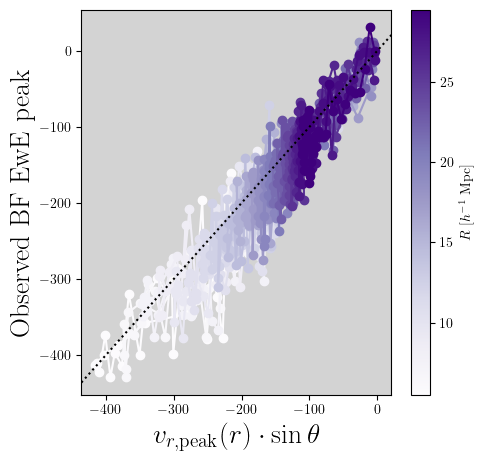

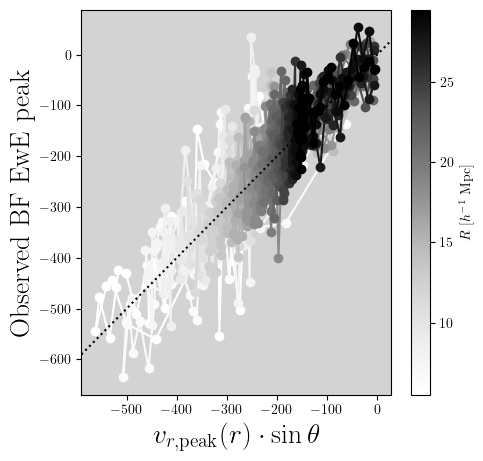

In [24]:

for k in range(0, len(Mvirs)):
    fig, ax = plt.subplots(1, figsize=(5, 5))

    for j in range(len(r_cens)):
        mask = rlos_cens < 40
        #EW_peak = EWpars[k, j, :, 0] + EWpars[k, j, :, 1]*( -0.5*EWpars[k, j, :, 2] + (5/16)*EWpars[k, j, :, 2]*EWpars[k, j, :, 3] - (23/48)*EWpars[k, j, :, 2]**3 )
        
        xs = np.linspace(-3000, 3000, 10_000)

        mu, sigma, gam1, gam2 = EWpars[k, j, :].T
        pdfs = [gam2_EW(xs, mu[i], sigma[i], gam1[i], gam2[i]) for i in range(len(rlos_cens))]
        
        EW_peak_obs = [xs[np.argmax(pdf)] for pdf in pdfs ]

        ax.plot(peaks[k, j], EW_peak_obs, c=cmaps[k][j], marker='o')
        ax.set_xlabel(r"$v_{r, \rm peak}(r)\cdot\sin\theta$", fontsize=20)
        ax.set_ylabel(r"Observed BF EwE peak", fontsize=20)


    ax.axline((0, 0), slope=1, ls=':', c='k')
    #ax.axline((0, 0), slope=1.3, ls='--', c='k')

    ax.set_facecolor('lightgray')

    Norm = Normalize(vmin=min(r_cens), vmax=max(r_cens))
    sm = ScalarMappable(norm=Norm, cmap=colormap_list[k])
    sm.set_array([])  # dummy array
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r"$R \ [h^{-1}$ Mpc]")

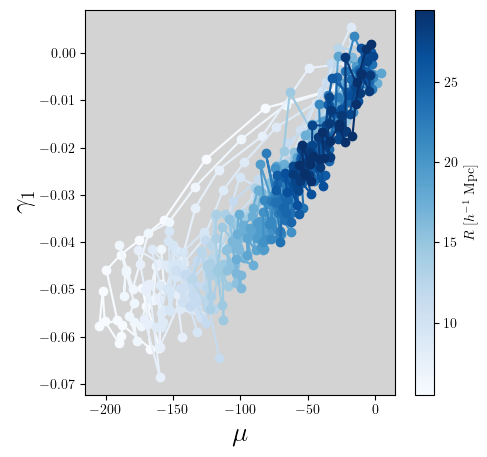

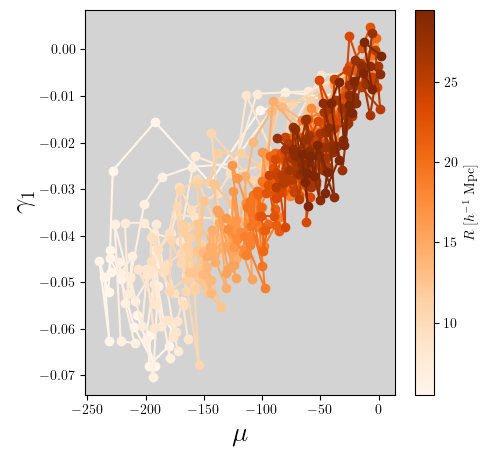

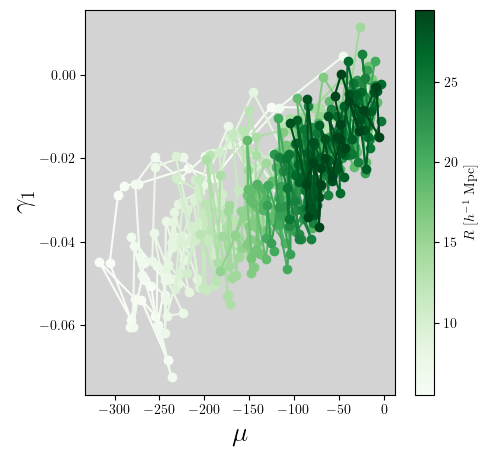

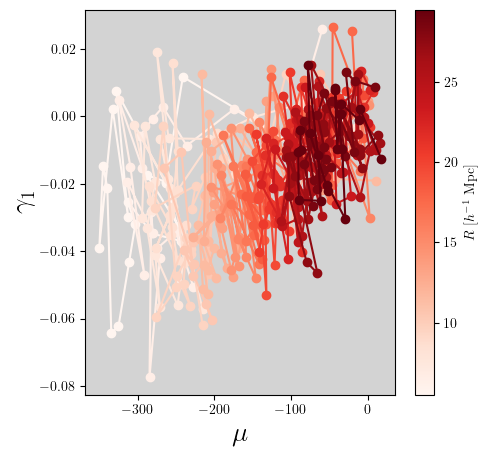

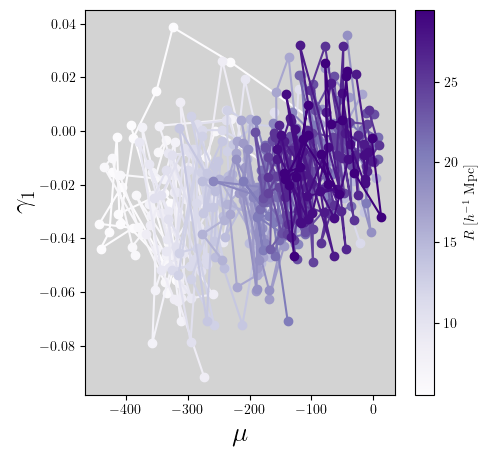

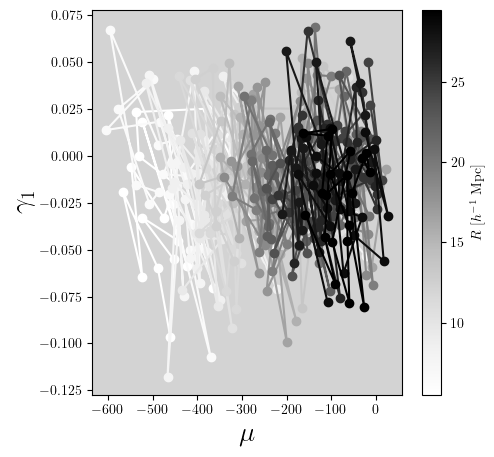

In [201]:

for k in range(0, len(Mvirs)):
    fig, ax = plt.subplots(1, figsize=(5, 5))

    for j in range(len(r_cens)):
        mask = rlos_cens < 20
        EW_peak = EWpars[k, j, :, 0] + EWpars[k, j, :, 1]*( -0.5*EWpars[k, j, :, 2] + (5/16)*EWpars[k, j, :, 2]*EWpars[k, j, :, 3] - (23/48)*EWpars[k, j, :, 2]**3 )
        ax.plot(EW_peak[mask], EWpars[k, j, :, 2][mask], c=cmaps[k][j], marker='o')
        ax.set_xlabel(r"$\mu$", fontsize=20)
        ax.set_ylabel(r" $\gamma_1$", fontsize=20)


    #ax.axline((0, 0), slope=1, ls=':', c='k')
    #ax.axline((0, 0), slope=1.3, ls='--', c='k')

    ax.set_facecolor('lightgray')

    Norm = Normalize(vmin=min(r_cens), vmax=max(r_cens))
    sm = ScalarMappable(norm=Norm, cmap=colormap_list[k])
    sm.set_array([])  # dummy array
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r"$R \ [h^{-1}$ Mpc]")

(0.0, 0.29424756561881893)

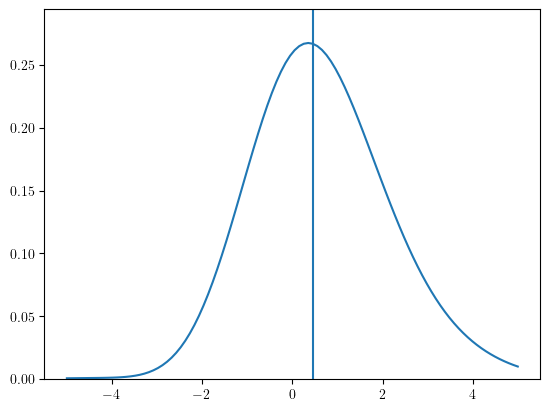

In [28]:
xs = np.linspace(-5, 5, 100)


mu = 0.5
sigma=1.5
g1 = 0.05
g2 = 0.01

dist = gam2_EW(xs, mu, sigma, g1, g2)

plt.plot(xs, dist)
plt.axvline(mu + sigma*(-g1/2 + (5/16)*g1*g2 - (23/48)*g1**3  ))
plt.ylim(0, 1.1*np.max(dist))

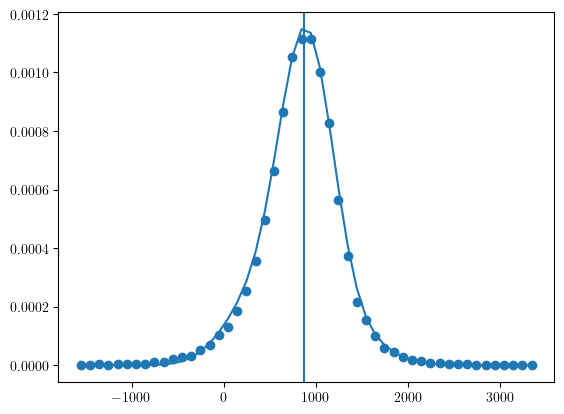

In [33]:
i, j, k = 10, 10, 0

index = i + j*len(rlos_cens) + (k//5)*len(r_cens)*len(rlos_cens)

r = np.sqrt(r_cens[j]**2 + rlos_cens[i]**2)
theta = np.arctan2(rlos_cens[i], r_cens[j])
sin = np.sin(theta)


peak = interps[k](r)*sin + a*H*rlos_cens[i]/h

ve = np.linspace(peak-2500, peak+2500, 50+1)
vc = 0.5*(ve[1:] + ve[:-1])

hist, edges = np.histogram(vphyslos1[index], bins=ve, density=True)
cent = 0.5*(edges[1:] + edges[:-1])

p, c = curve_fit(gam2_EW, cent, hist, p0=[peak, 400, 0.1, 0.1])

plt.scatter(cent, hist)
plt.plot(cent, gam2_EW(cent, p[0], p[1], p[2], p[3]))
plt.axvline(p[0] + p[1]*(-p[2]/2 + (5/16)*p[2]*p[3] - (23/48)*p[2]**3  ))
